# Задача 7. Нейронные сети

* **Основной полный балл**: 5
* **Максимум баллов**: 10

## Задача

- Найти данные в виде изображений для задачи классификации. Например, можно взять данные [отсюда](http://ufldl.stanford.edu/housenumbers/).
- Реализовать классы, необходимые для построения сети со следующими слоями
	- FullyConnectedLayer
	- ReluLayer
	- FullyConnectedLayer
- Использовать CrossEntropyLoss и L2-регуляризацию.
- Обучить модель на тренировочных данных, подбирать параметры (особенно learning rate) на валидационной и оценить качество на тестовой. Анализировать графики train/val loss, проверять на каждом шаге корректность вычисления градиентов с помощью разностной оценки.
- (**+2 балла**) Добавить Batch normalization.
- (**+2 балла**) В качестве оптимизатор использовать один из: Momentum, RMSprop.
-  (**+1 балл**) Также реализовать оптимизатор Adam.

In [47]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import itertools
import math
import torch.nn as nn
import pytorch_lightning as L
import seaborn as sns
import os
import torch.nn.functional as F


from torch import matmul
from torch.optim import SGD, RMSprop
from typing import Any
from torch import nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.optim.optimizer import Optimizer
from lightning.pytorch.loggers import CSVLogger
from glob import glob
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, Normalize, RandomHorizontalFlip, RandomRotation
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import Optimizer
from matplotlib.ticker import MaxNLocator
from tabulate import tabulate
from pytorch_lightning.loggers import CSVLogger

In [ ]:
DATASET_PATH = "./dataset"
RANDOM_SEED = 123
WORKERS = 10
BATCH_SIZE = 4096
VAL_SIZE = 0.2

GRAD_CHECK_INTERVAL = 100
MOMENTUM = 0.9
ALPHA = 0.99

HP_EPOCHS = 3
LEARNING_EPOCHS = 15
INFO_DIR = "res"

HP_DIR = "mnist_params"
RESULT_DIR = "mnist_final"

### Датасет

[MNIST](https://www.kaggle.com/code/geekysaint/solving-mnist-using-pytorch) — датасет, который содержит 70000 изображений в оттенках серого нарисованных от руки цифр размером 28 на 28 пикселей.

In [ ]:
complete_train_data = MNIST(
    root=DATASET_PATH,
    download=True,
    train=True,
)

test_data = MNIST(
    root=DATASET_PATH,
    download=True,
    train=False,
)

train_idx, valid_idx = train_test_split(
    list(range(len(complete_train_data))),
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=complete_train_data.targets.numpy()
)

train_dataset = Subset(complete_train_data, train_idx)
valid_dataset = Subset(complete_train_data, valid_idx)

training_loader, validation_loader, testing_loader = (
            DataLoader(prepared_set, batch_size=BATCH_SIZE, num_workers=WORKERS, shuffle=shaf_opt) for (prepared_set, shaf_opt) in [
                (train_dataset, True), 
                (valid_dataset, False), 
                (test_data, False)
            ]
        )

print(f"Training Examples: {len(train_dataset)}, Validation Examples: {len(valid_dataset)}, Testing Examples: {len(test_data)}")


Training Examples: 48000, Validation Examples: 12000, Testing Examples: 10000


### Реализация Adam

In [50]:
class CustomAdam(Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, 
                 weight_decay=0.0, amsgrad=False):
        config = {
            'lr': lr,
            'betas': betas,
            'eps': eps,
            'weight_decay': weight_decay,
            'amsgrad': amsgrad
        }
        super().__init__(params, config)

    @torch.no_grad()
    def step(self, closure=None):
        computed_loss = None
        if closure is not None:
            with torch.enable_grad():
                computed_loss = closure()

        for group in self.param_groups:
            beta1, beta2 = group['betas']
            lr = group['lr']
            eps = group['eps']
            decay = group['weight_decay']
            amsgrad_enabled = group['amsgrad']

            for param in group['params']:
                if param.grad is None:
                    continue

                grad_tensor = param.grad
                param_state = self.state[param]

                if not param_state:
                    param_state['step'] = 0
                    param_state['m'], param_state['v'] = torch.zeros_like(param), torch.zeros_like(param)
                    if amsgrad_enabled:
                        param_state['v_hat'] = torch.zeros_like(param)

                if decay != 0:
                    grad_tensor = grad_tensor.add(param, alpha=decay)

                param_state['step'] += 1
                step_count = param_state['step']

                m, v = param_state['m'], param_state['v']

                m.mul_(beta1).add_(grad_tensor, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(grad_tensor, grad_tensor, value=1 - beta2)

                bias_correction1 = 1 - beta1 ** step_count
                bias_correction2 = 1 - beta2 ** step_count

                if amsgrad_enabled:
                    v_hat = param_state['v_hat']
                    torch.maximum(v_hat, v, out=v_hat)
                    denom = (v_hat.sqrt() / math.sqrt(bias_correction2)).add_(eps)
                else:
                    denom = (v.sqrt() / math.sqrt(bias_correction2)).add_(eps)

                update_scale = lr / bias_correction1
                param.addcdiv_(m, denom, value=-update_scale)

        return computed_loss

### Реализация слоёв нейронной сети

1. **Полносвязный (LinearBlock)**  
2. **Активации (ActivationRelu)**  

- Наличие `forward` и `backward` проходов.  

In [51]:
class LinearBlock(nn.Module):
    def __init__(self, in_features, out_features, dtype=torch.float32):
        super().__init__()
        self.weights = nn.Parameter(torch.empty(in_features, out_features, dtype=dtype))
        self.biases = nn.Parameter(torch.empty(out_features, dtype=dtype))
        nn.init.kaiming_normal_(self.weights, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.biases)

    def forward(self, x):
        self.stored_input = x
        return matmul(x, self.weights) + self.biases

    def backward(self, grad_output):
        return (
            matmul(grad_output, self.weights.T), 
            matmul(self.stored_input.T, grad_output), 
            grad_output.sum(axis=0)
        )


class ActivationRelu(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        self.active_mask = torch.gt(x, 0)
        return x * self.active_mask

    def backward(self, grad_output):
        return grad_output * self.active_mask

### Реализация нейронной сети

Класс `Wrapper` на основе `LightningModule` инкапсулирует логику обучения/валидации/тестирования нейросети.

Особенности:
  - валидация градиентов (`_check_gradients`) методом конечных разностей
  - `h_size` — размер скрытого слоя  
  - `use_bn` — флаг применения BatchNorm    
  - поддержка L2-регуляризации через `wd` (`weight_decay`) 
  - `cross_entropy` (из пакета `torch.nn.functional`)


In [ ]:
class Wrapper(L.LightningModule):
    def __init__(self, h_size=256, use_bn=False, optimizer_type='CustomAdam', learning_rate=1e-3, wd=0.005):
        class FeedForwardNet(nn.Module):
            def __init__(self, h_size=256, use_bn=False, in_dim=784, out_dim=10):
                super().__init__()
                self.layer1 = LinearBlock(in_dim, h_size)
                self.activation = ActivationRelu()
                self.norm = nn.BatchNorm1d(h_size) if use_bn else nn.Identity()
                self.layer2 = LinearBlock(h_size, out_dim)

            def forward(self, input_tensor):
                return (self.layer2(self.norm(self.activation(self.layer1(input_tensor)))))

        super().__init__()
        self.network = FeedForwardNet(h_size, use_bn)
        self.save_hyperparameters(dict(optimizer_type=optimizer_type, learning_rate=learning_rate, wd=wd))

    def forward(self, input_data):
        return self.network(input_data)

    def _compute_loss(self, model, batch_data):
        samples, targets = batch_data
        samples = samples.view(samples.size(0), -1)
        predictions = model(samples)
        return F.cross_entropy(predictions, targets)

    def _compute_accuracy(self, model, batch_data):
        samples, targets = batch_data
        samples = samples.view(samples.size(0), -1)
        preds = model(samples)
        correct = preds.argmax(dim=1) == targets
        return correct.float().mean()

    def training_step(self, batch_data, idx):
        x_data, y_data = batch_data
        x_data = x_data.view(x_data.size(0), -1)
        logits = self.network(x_data)
        loss_value = F.cross_entropy(logits, y_data)

        self.log('train_loss', loss_value, on_step=True)

        if idx % GRAD_CHECK_INTERVAL == 0:
            self._check_gradients(x_data, y_data)

        return loss_value

    def _check_gradients(self, x_val, y_val):
        param_snapshot = {k: v.detach().clone() for k, v in self.network.named_parameters()}

        for key, param in self.network.named_parameters():
            if param.grad is None:
                continue

            analytic = param.grad.detach().clone()
            numeric = torch.zeros_like(param.data)

            for idx in range(param.numel()):
                flat = param.data.view(-1)

                flat[idx] += self._EPS
                loss1 = F.cross_entropy(self.network(x_val), y_val).item()

                flat[idx] -= 2 * self._EPS
                loss2 = F.cross_entropy(self.network(x_val), y_val).item()

                flat[idx] += self._EPS
                numeric.view(-1)[idx] = (loss1 - loss2) / (2 * self._EPS)

            diff = torch.norm(analytic - numeric) / (torch.norm(analytic) + torch.norm(numeric) + 1e-8)

            if diff > 1e-3:
                print(f"ALERT: Gradient mismatch on {key}: {diff:.4f}")

        for name, p in self.network.named_parameters():
            p.data.copy_(param_snapshot[name])

    def validation_step(self, val_batch):
        acc = self._compute_accuracy(self.network, val_batch)
        val_loss = self._compute_loss(self.network, val_batch)

        self.log('val_acc', acc, on_step=False, on_epoch=True)
        self.log('val_loss', val_loss, on_step=False, on_epoch=True)

    def test_step(self, test_data):
        accuracy = self._compute_accuracy(self.network, test_data)
        self.log('test_acc', accuracy, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        optimizers = {
            'SGD': SGD,
            'CustomAdam': CustomAdam,
            'RMSprop': RMSprop
        }
        
        opt_class = optimizers[self.hparams.optimizer_type]
        opt_params = {
            'params': self.parameters(),
            'lr': self.hparams.learning_rate,
            'weight_decay': self.hparams.wd
        }

        if self.hparams.optimizer_type == 'SGD':
            opt_params['momentum'] = MOMENTUM
        elif self.hparams.optimizer_type == 'RMSprop':
            opt_params['alpha'] = ALPHA

        return opt_class(**opt_params)

## Обучение

In [ ]:
def run_training(experiment_name, num_epochs, hyperparams):
    for hp_set in hyperparams:
        opt, learning_rate, h_size, use_bn = hp_set
        
        network = Wrapper(
            h_size=h_size,
            use_bn=use_bn,
            optimizer_type=opt,
            learning_rate=learning_rate,
        )
        log = CSVLogger(INFO_DIR, name=experiment_name)
        training_engine = L.Trainer(max_epochs=num_epochs, accelerator="cpu", logger=log, log_every_n_steps=5)
        log.log_hyperparams({
                "epochs": num_epochs,
                "learning_rate": learning_rate,
                "opt": opt,
                "h_size": h_size,
                "batchnorm": use_bn,
            })

        training_engine.validate(network, validation_loader)
        training_engine.fit(network, training_loader, validation_loader)
        training_engine.test(network, testing_loader)

### Оптимизация гиперпараметров

Для системного поиска оптимальных настроек применяется полный перебор возможных сочетаний.

**Исследуемые параметры:**
- **Алгоритмы оптимизации:** SDG, CustomAdam, RMSprop
- **Скорость обучения:** 0.01 и 0.001
- **Архитектурные особенности:**
  - Скрытый слой: 100 или 1000 нейронов
  - Применение Batch Normalization: включено/отключено

**Общее количество вариаций:** 24 (3 алгоритма × 2 значения lr × 2 размера слоя × 2 варианта BN)

**Процедура тестирования:**
1. **Предварительный анализ:** Оценка всех комбинаций в сокращенном режиме (3 эпохи)
2. **Углубленное обучение:** Детальная тренировка наиболее перспективных конфигураций (15 эпох)

In [ ]:
opts = ['SGD', 'CustomAdam', 'RMSprop']
lrs = [0.01, 0.001]
h_sizes = [100, 1000]
norm_opts = [True, False]
hparams = list(itertools.product(opts, lrs, h_sizes, norm_opts))
print(f"Total experiments to run: {len(hparams)}")
run_training(HP_DIR, HP_EPOCHS, hparams)

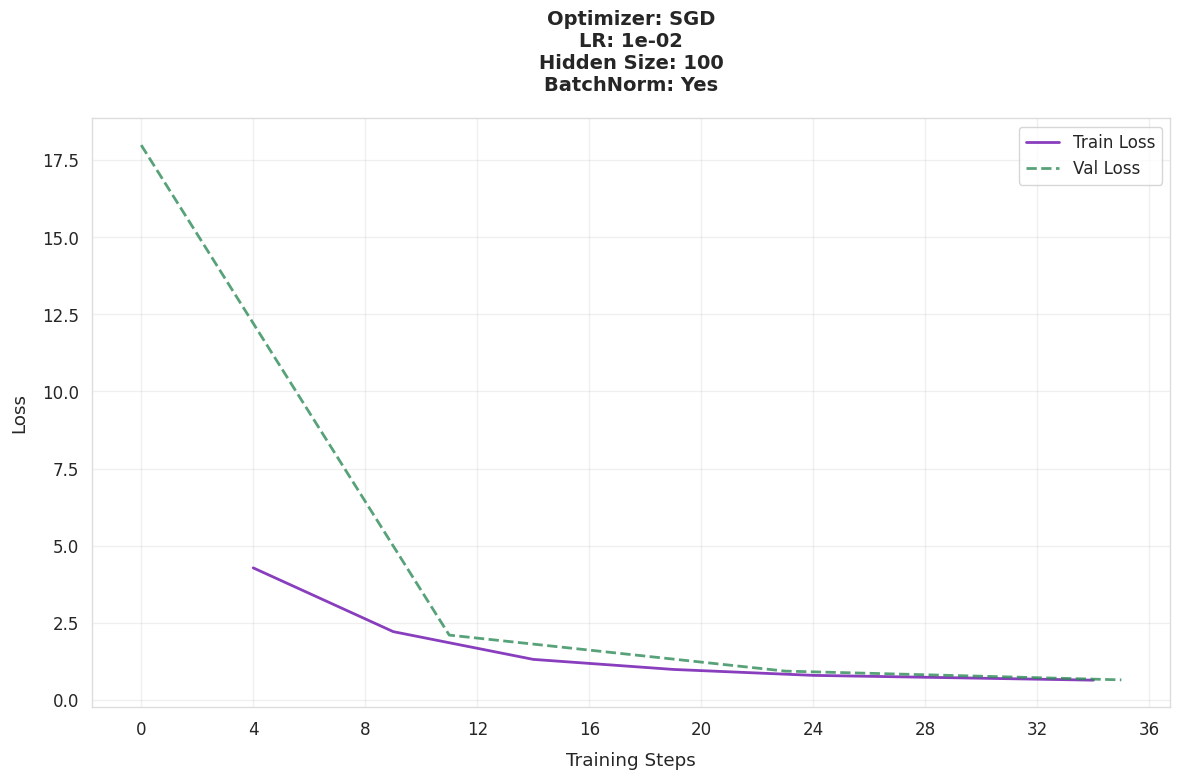

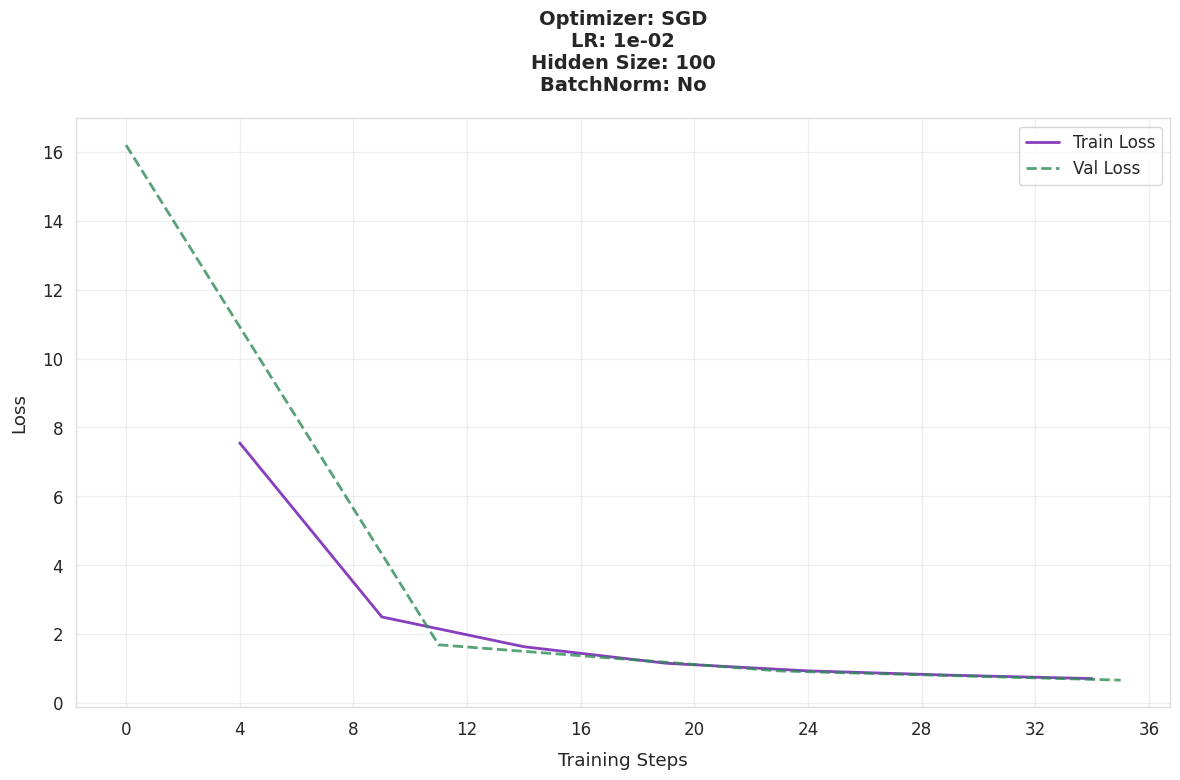

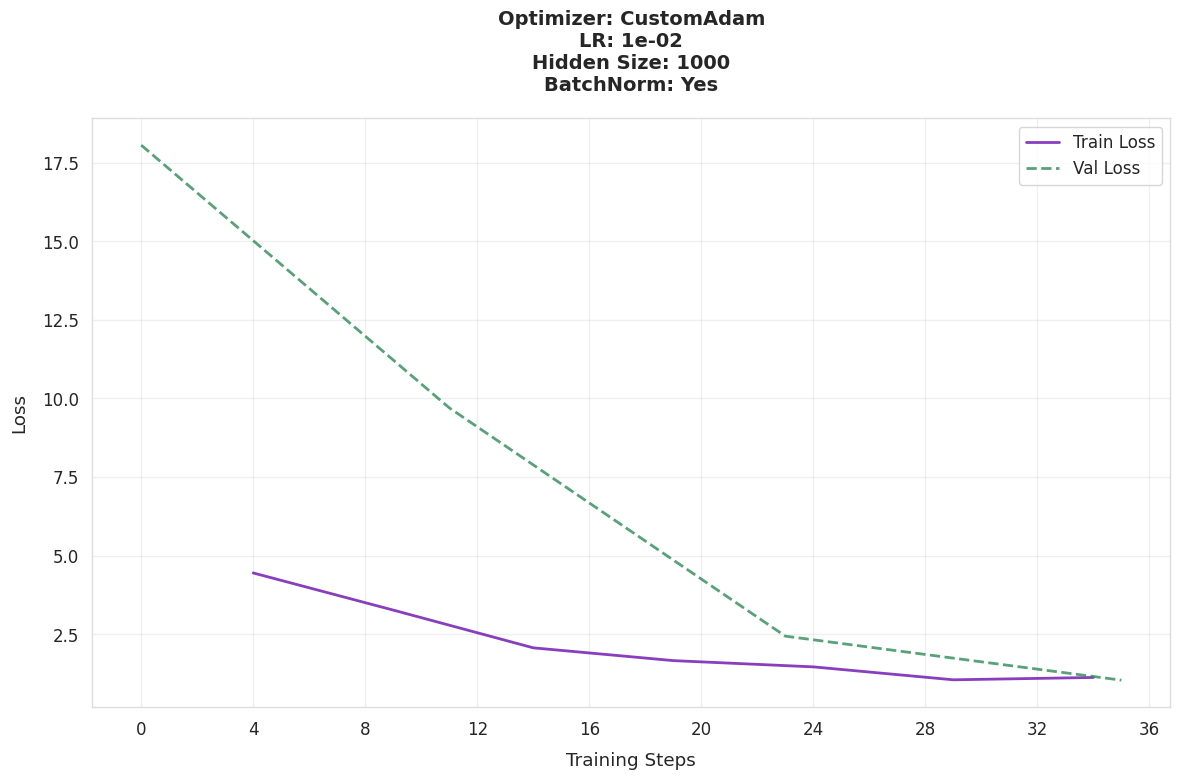

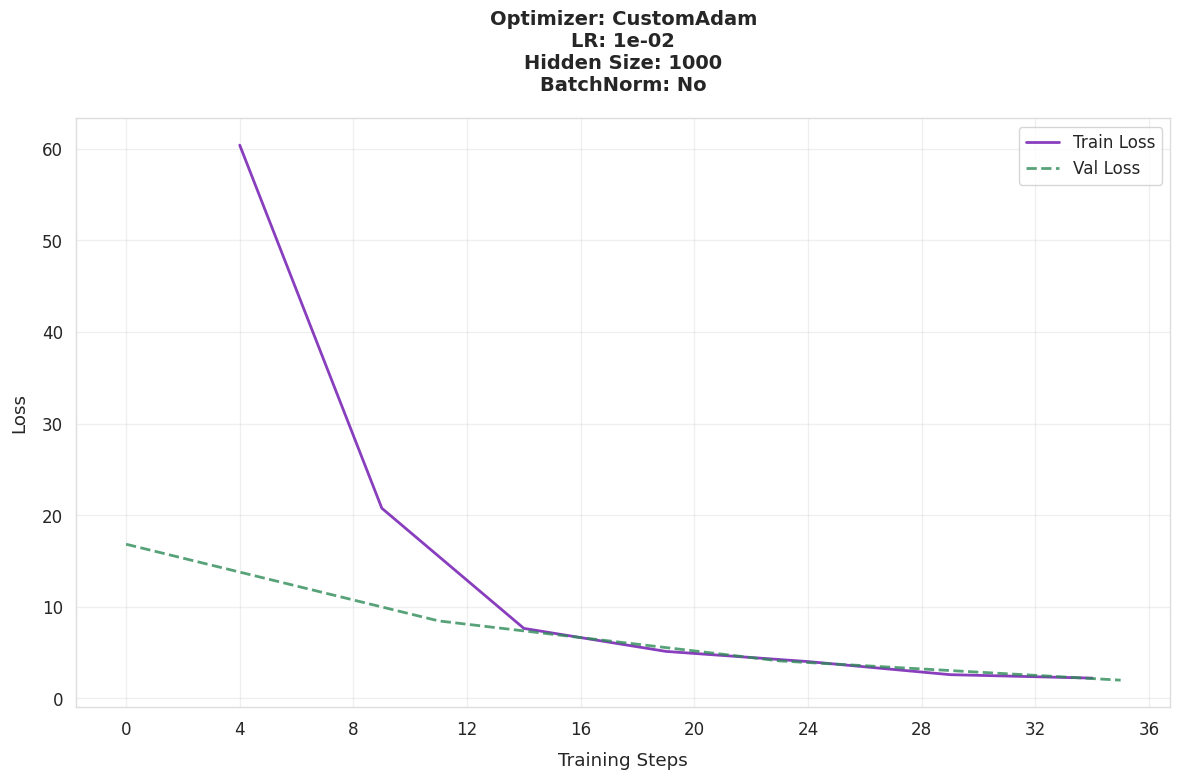

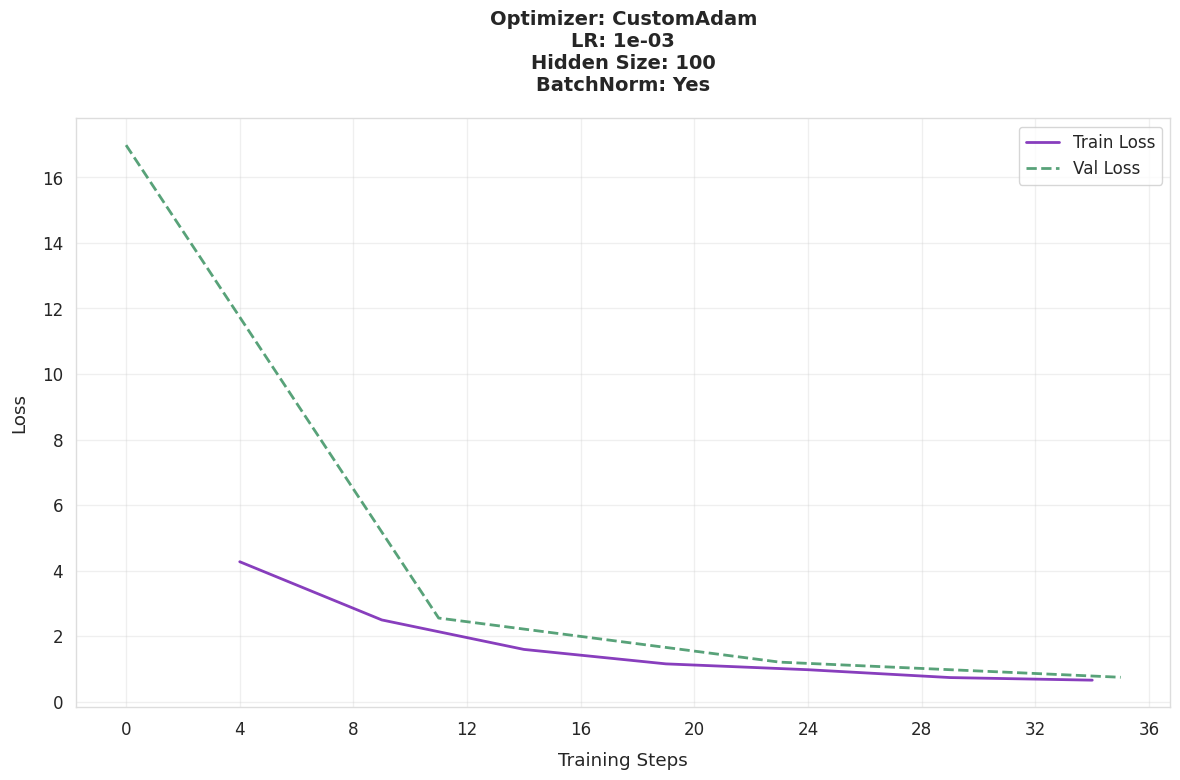

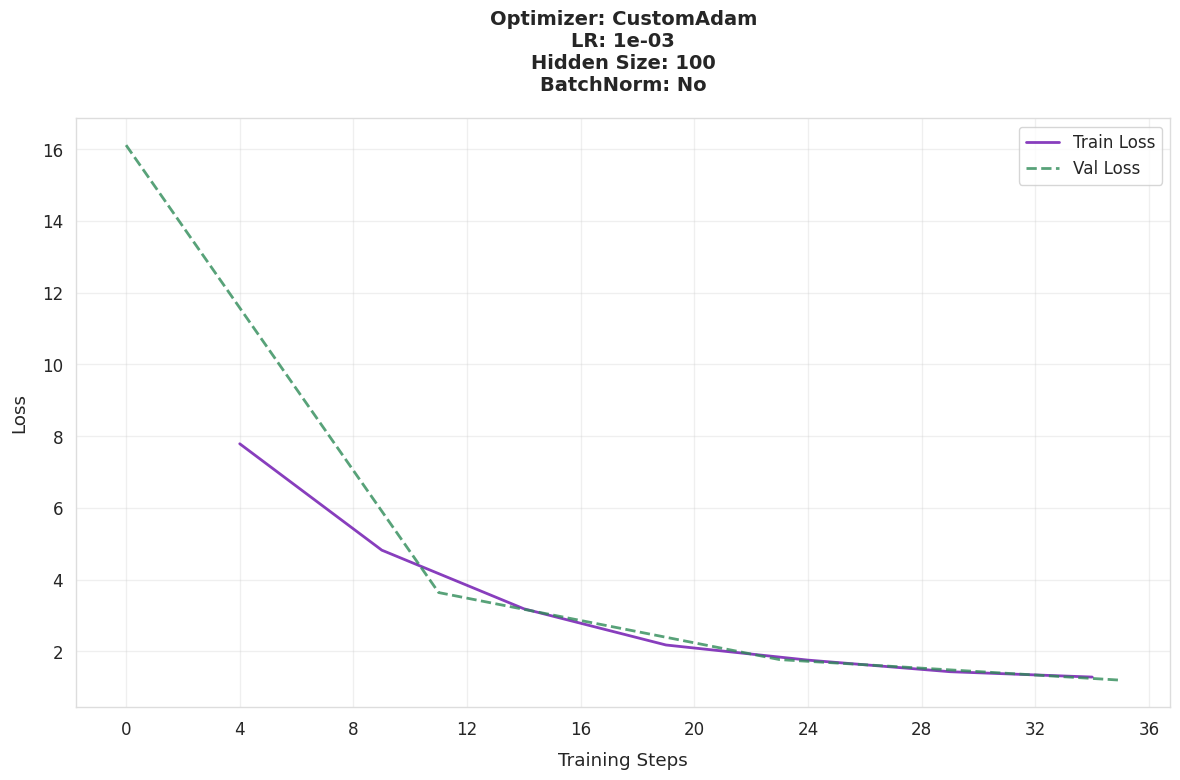

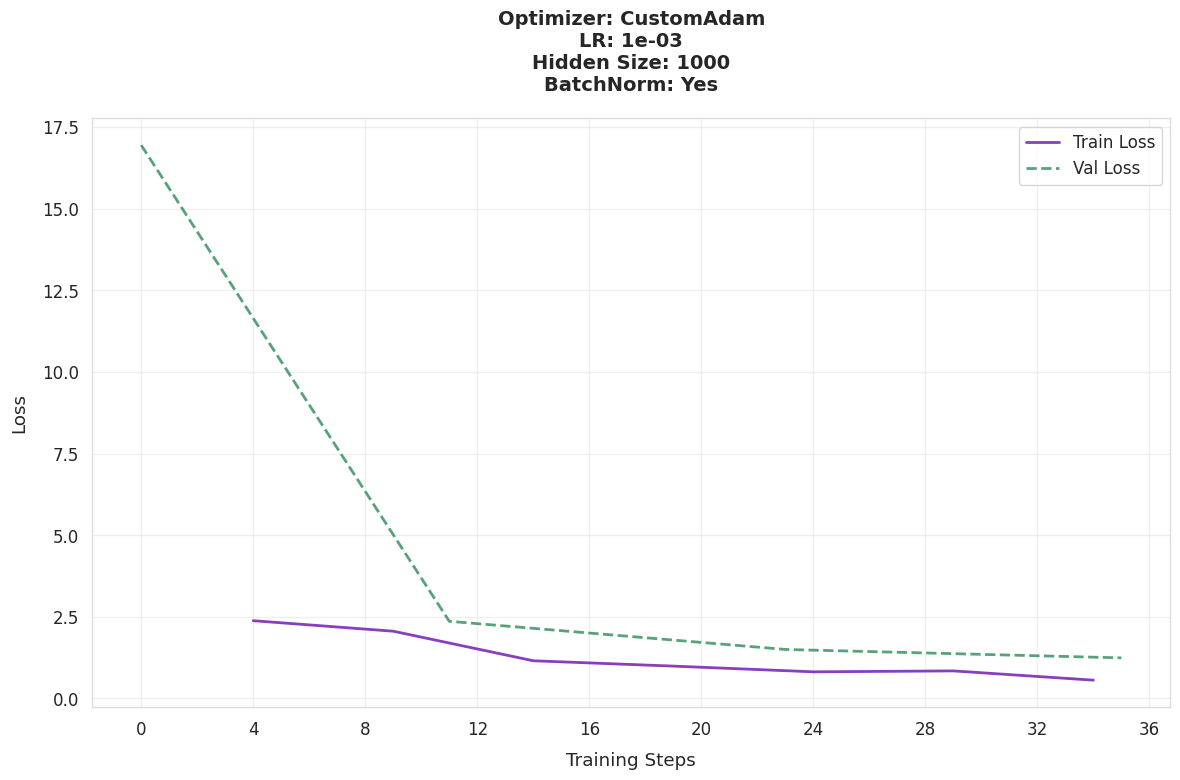

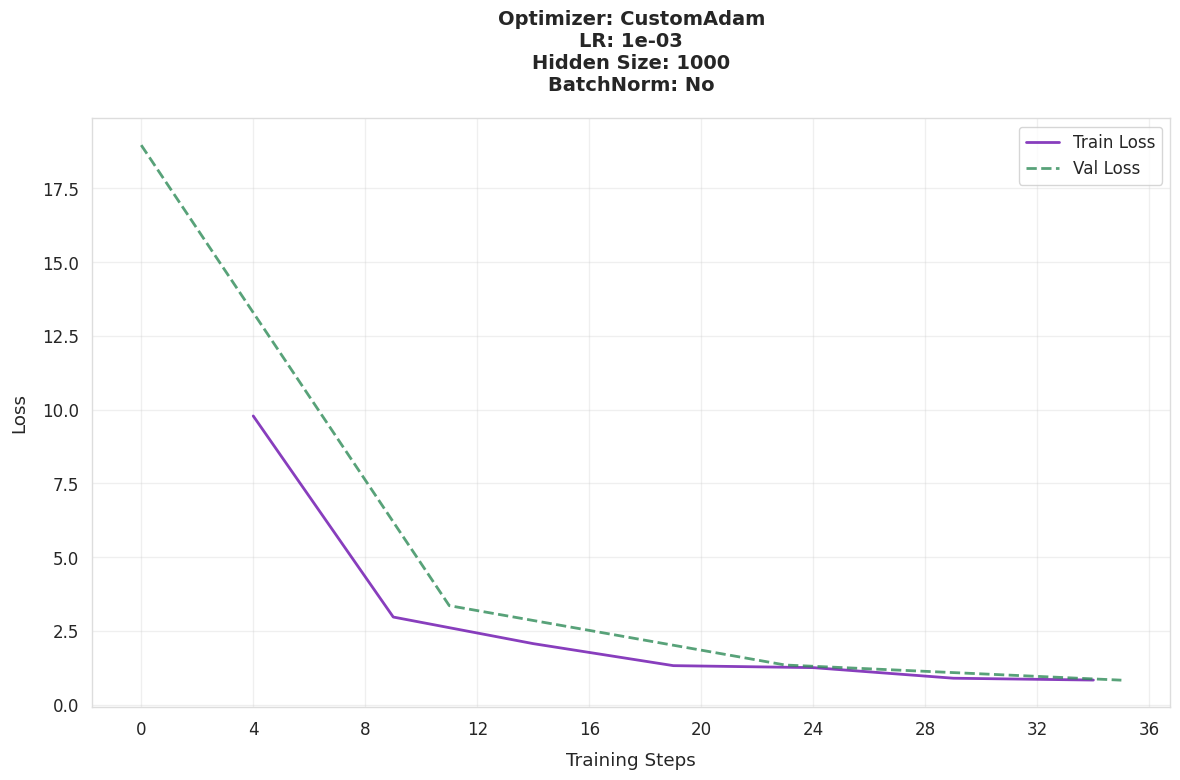

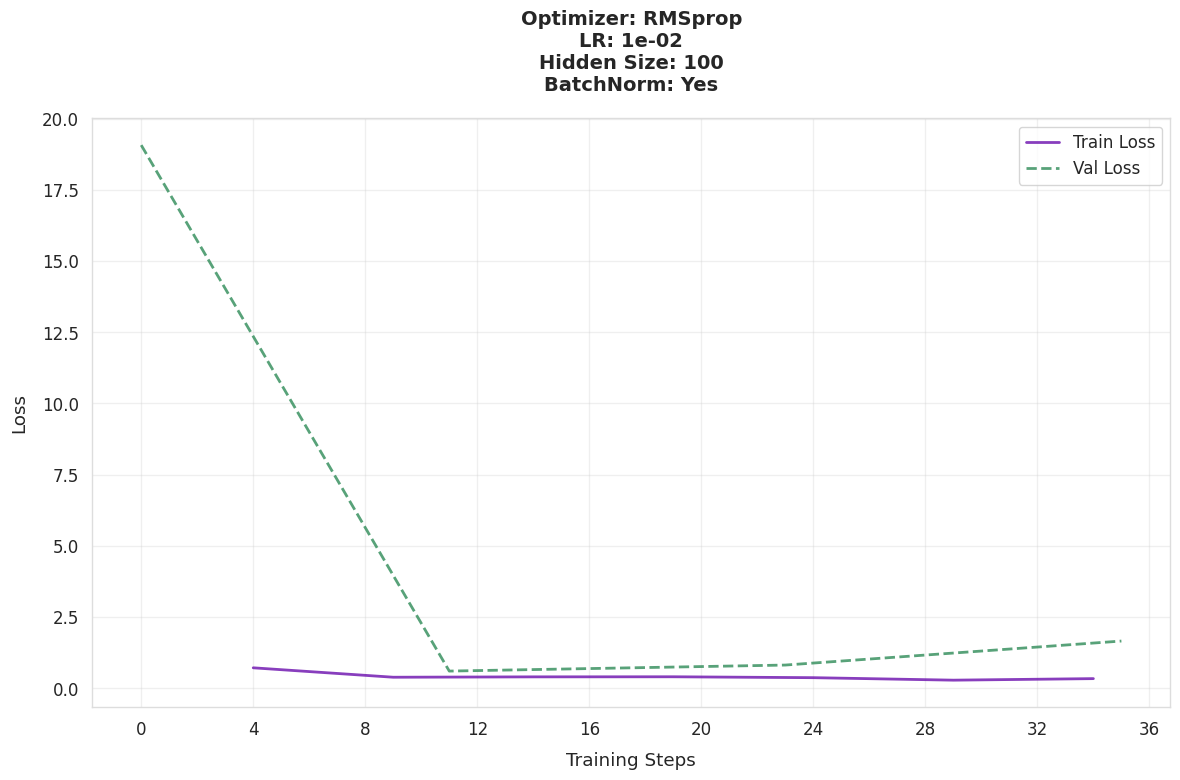

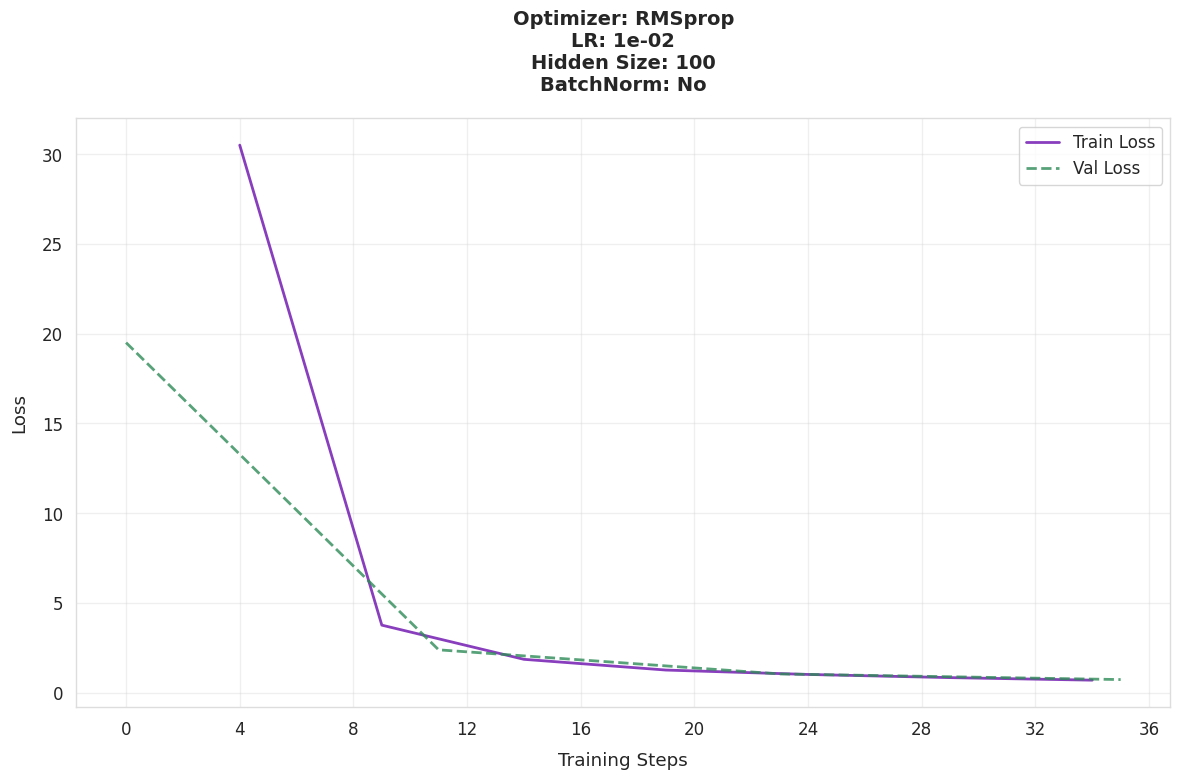

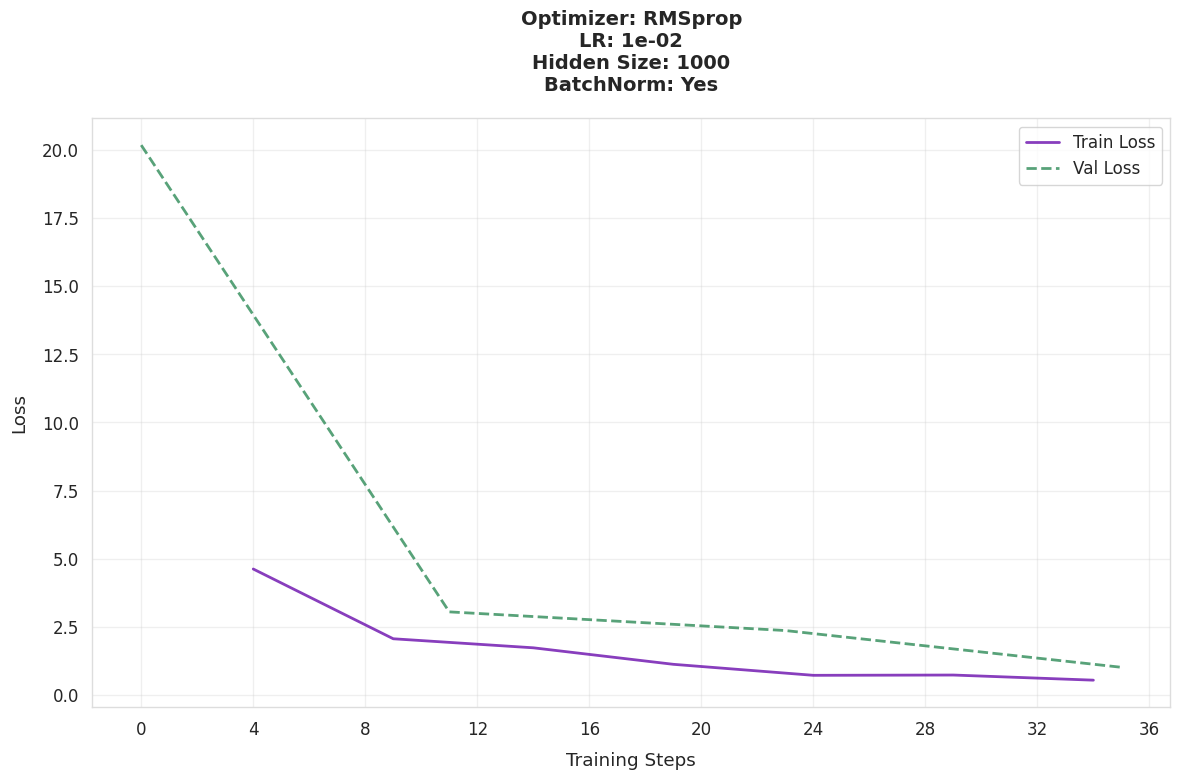

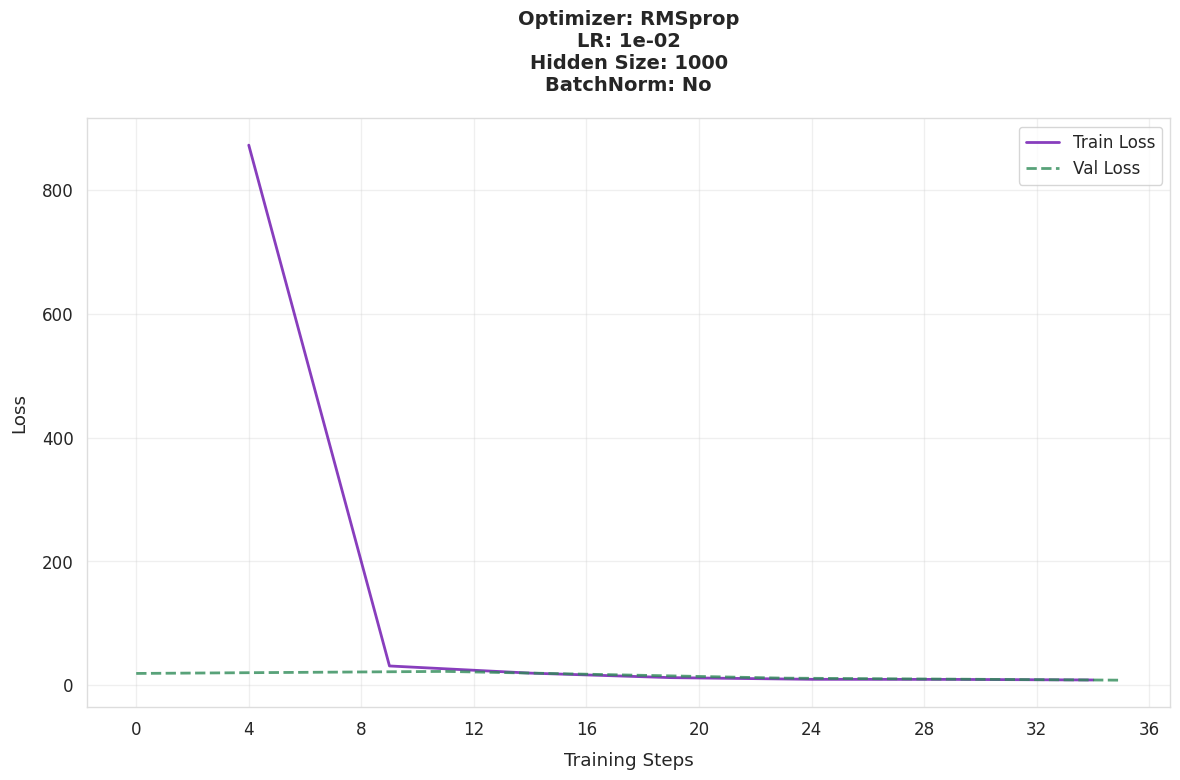

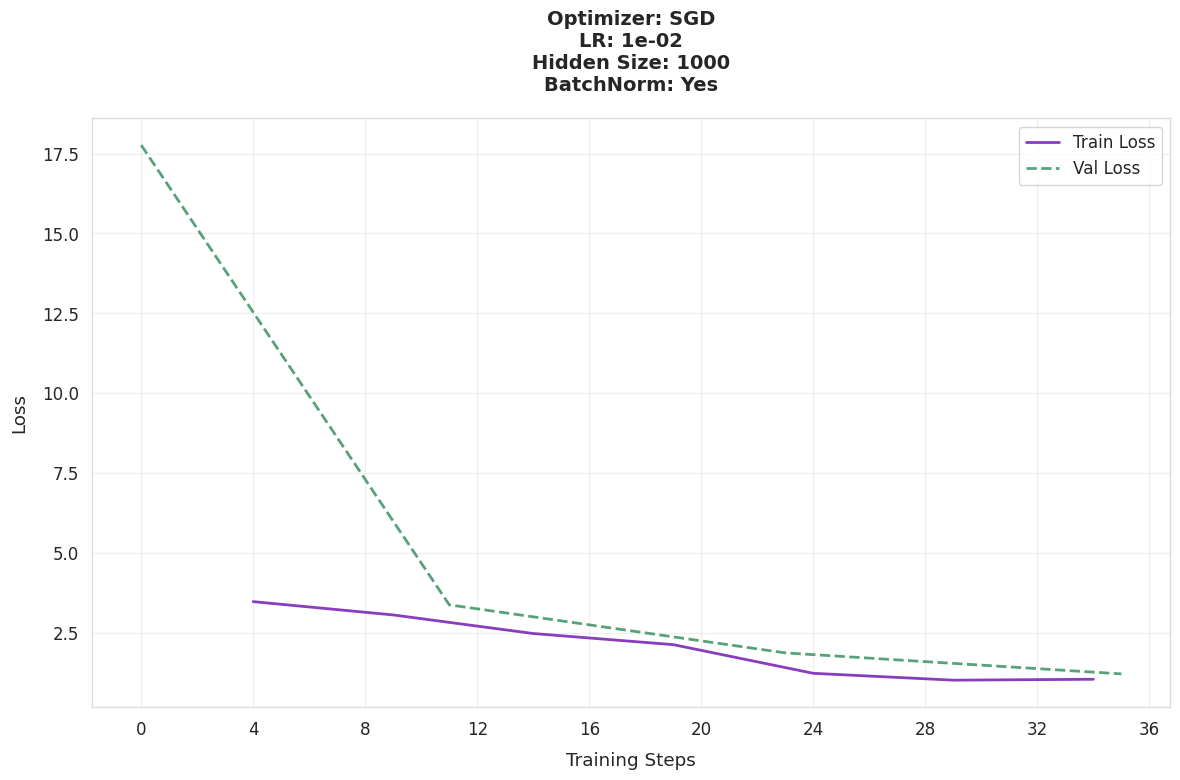

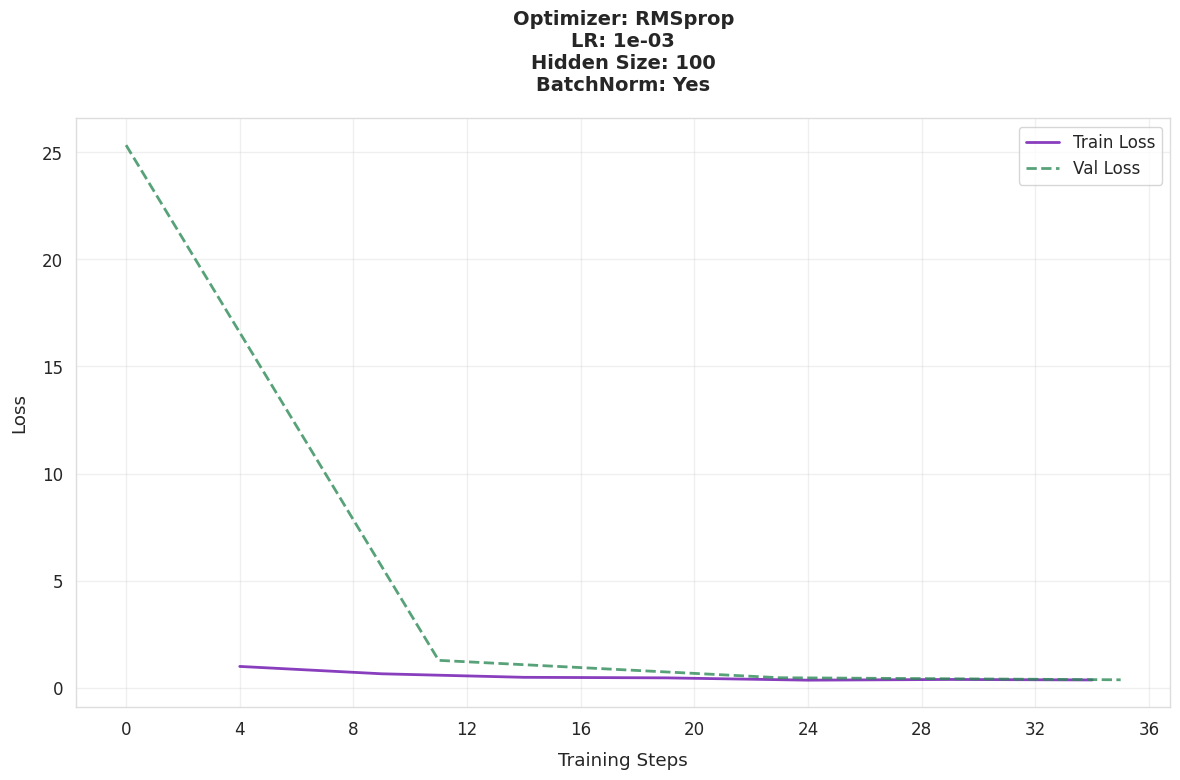

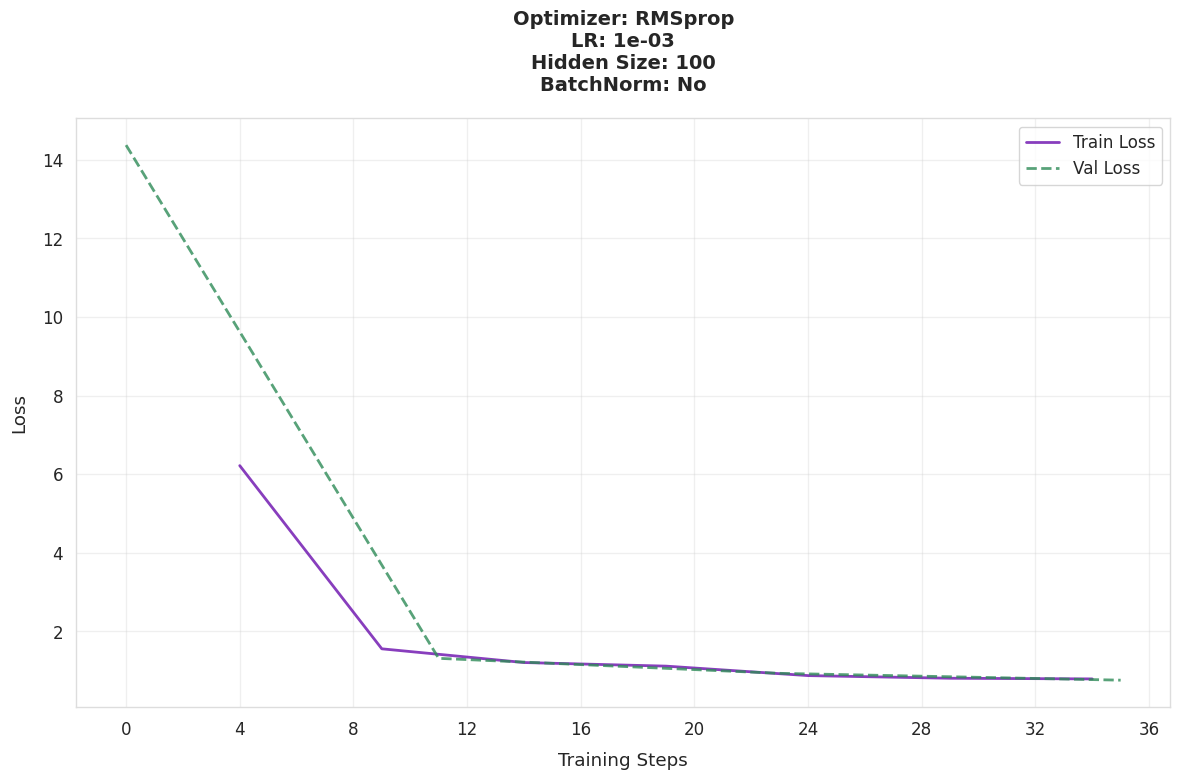

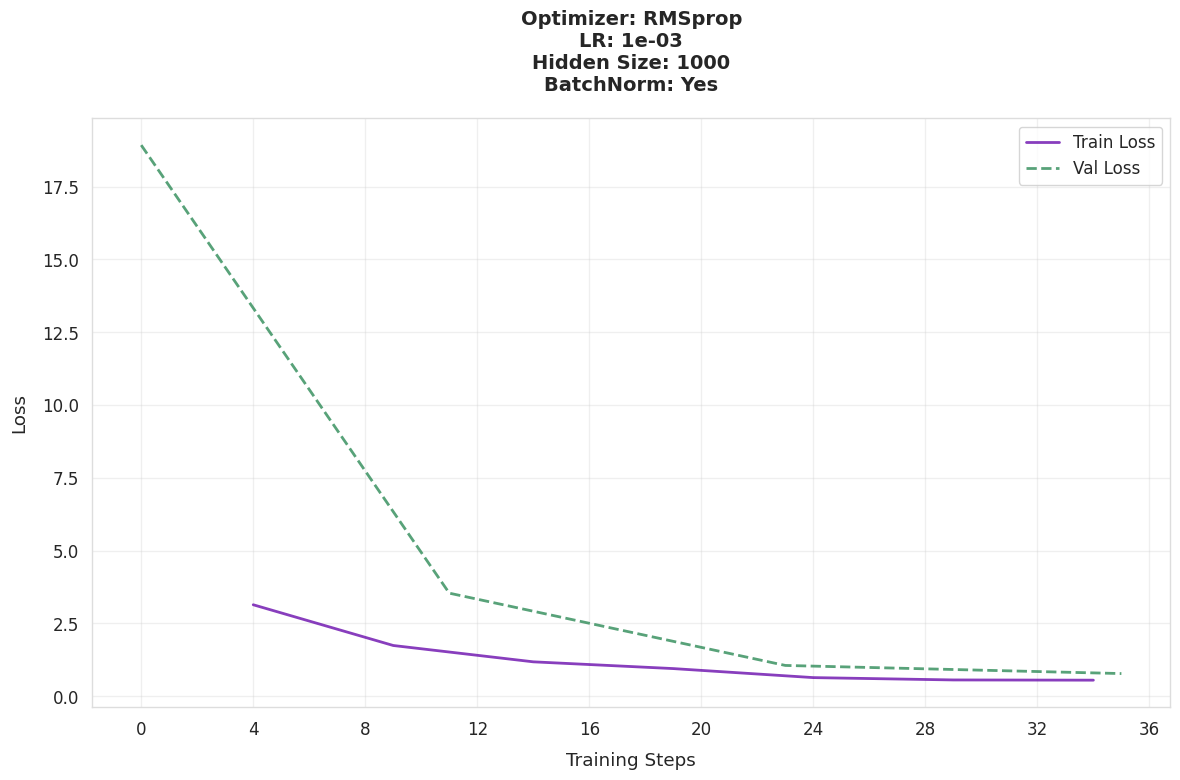

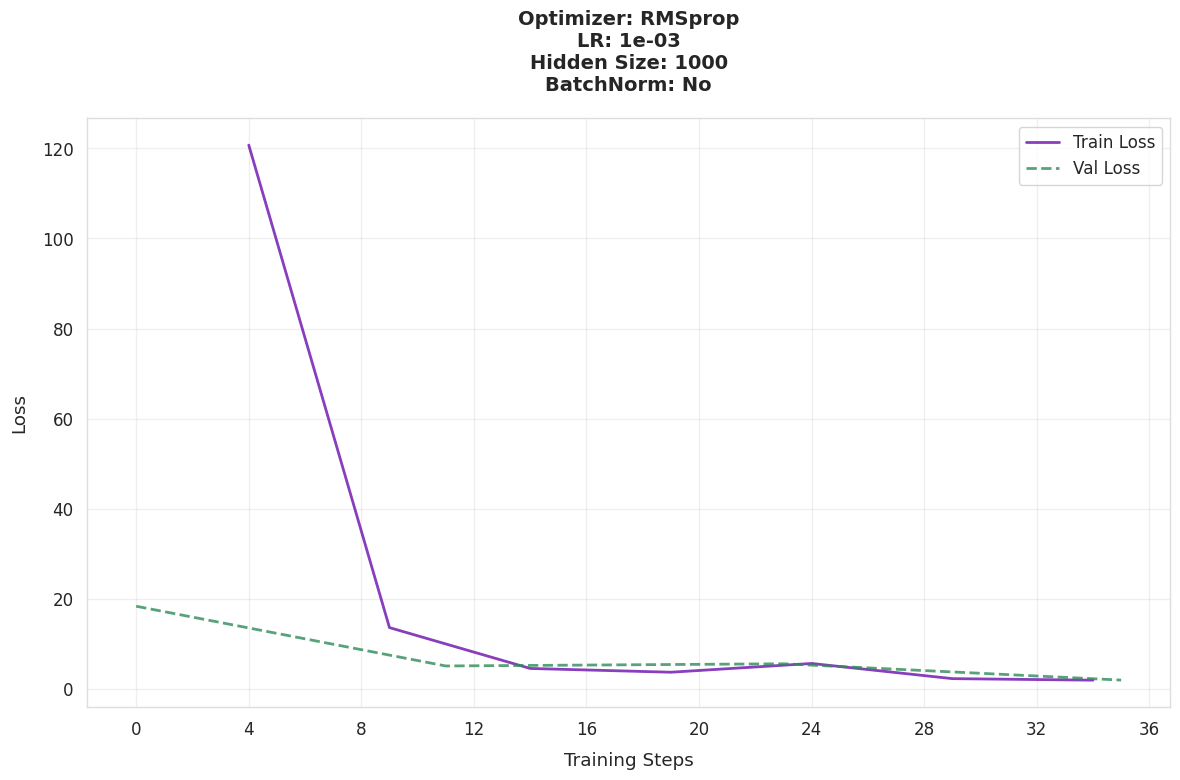

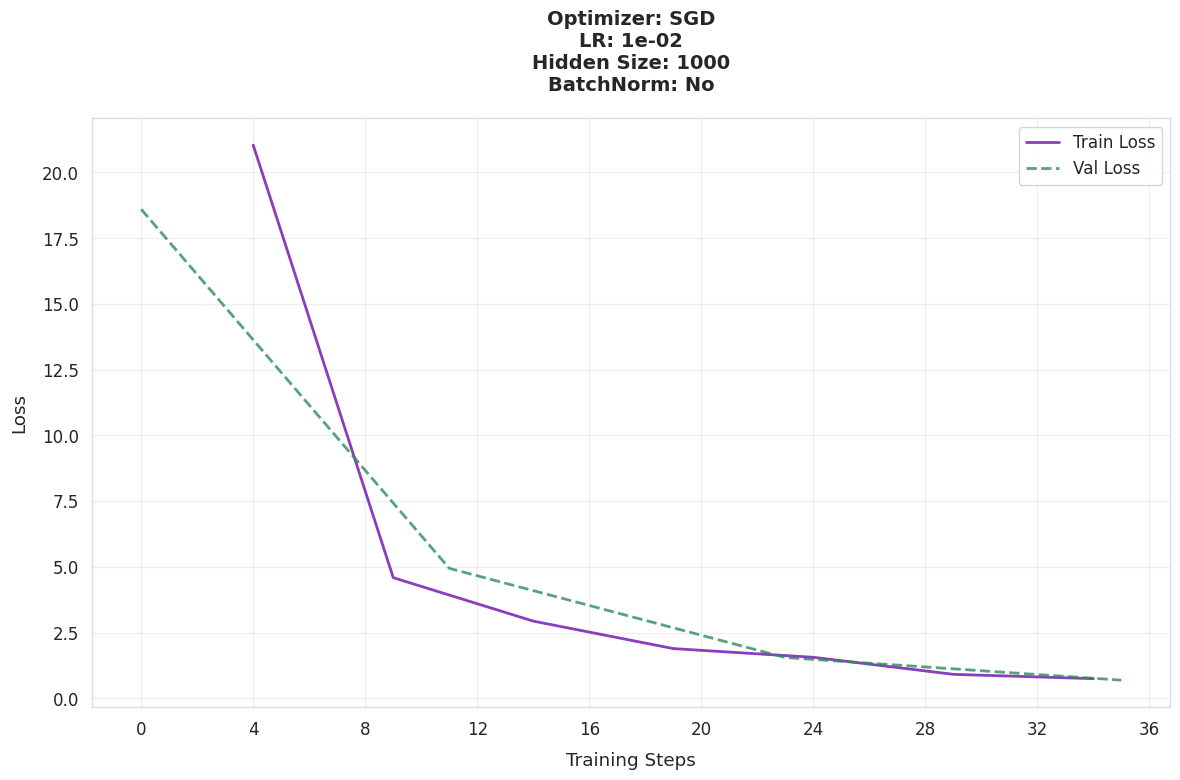

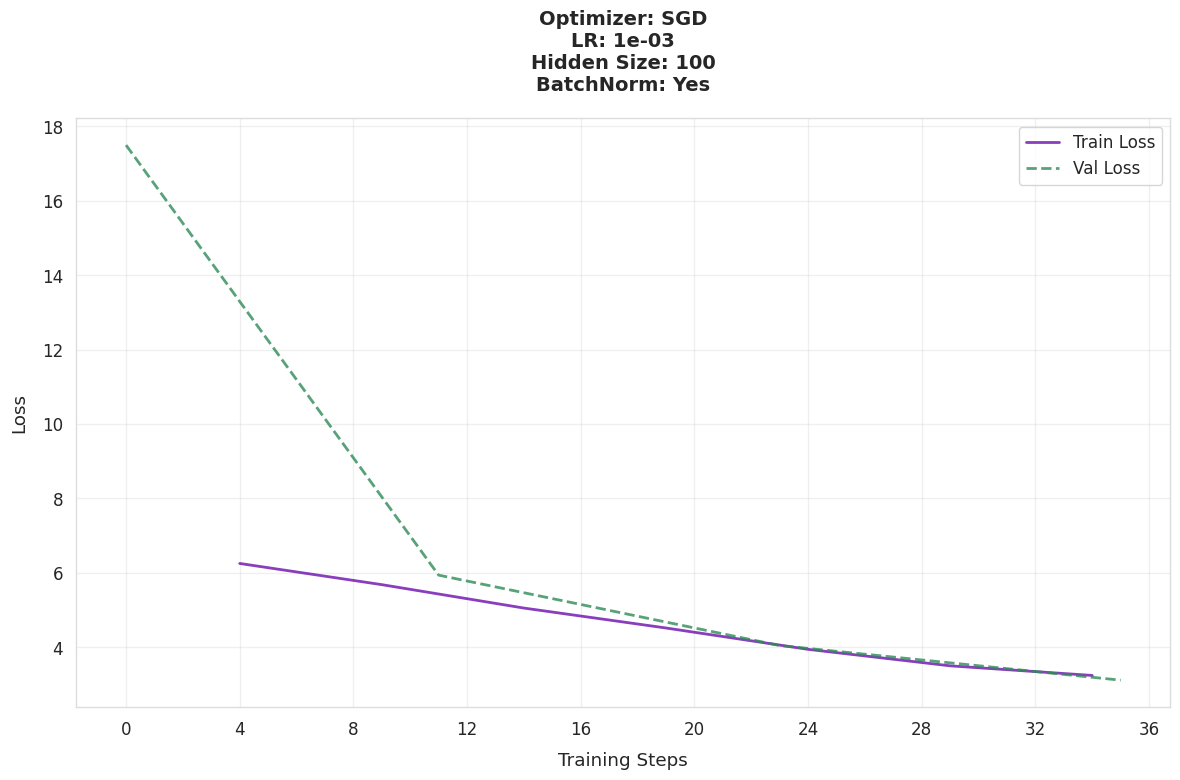

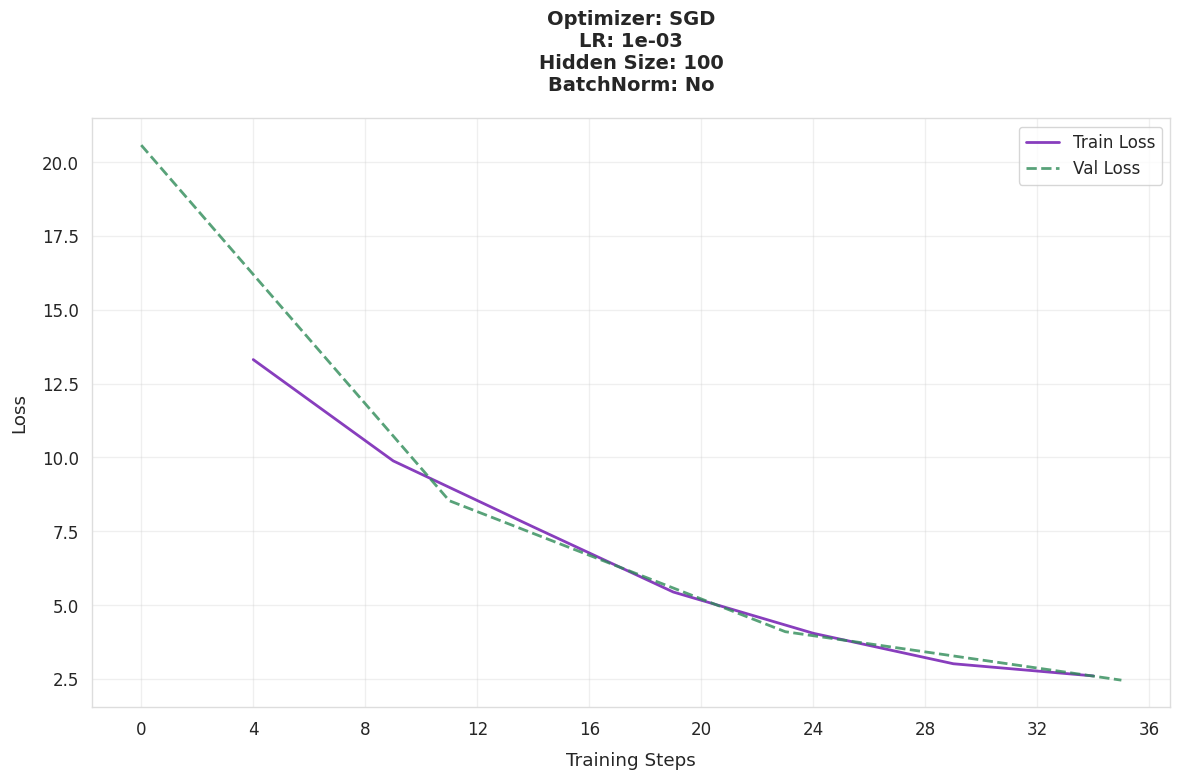

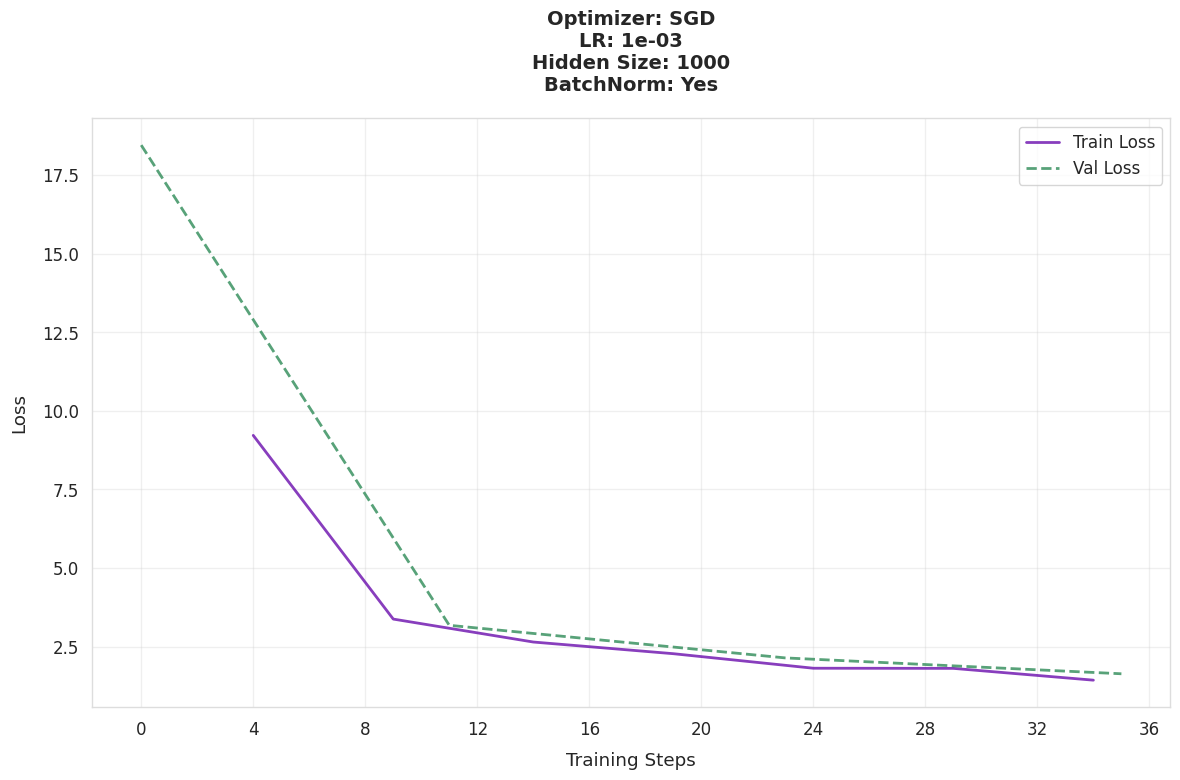

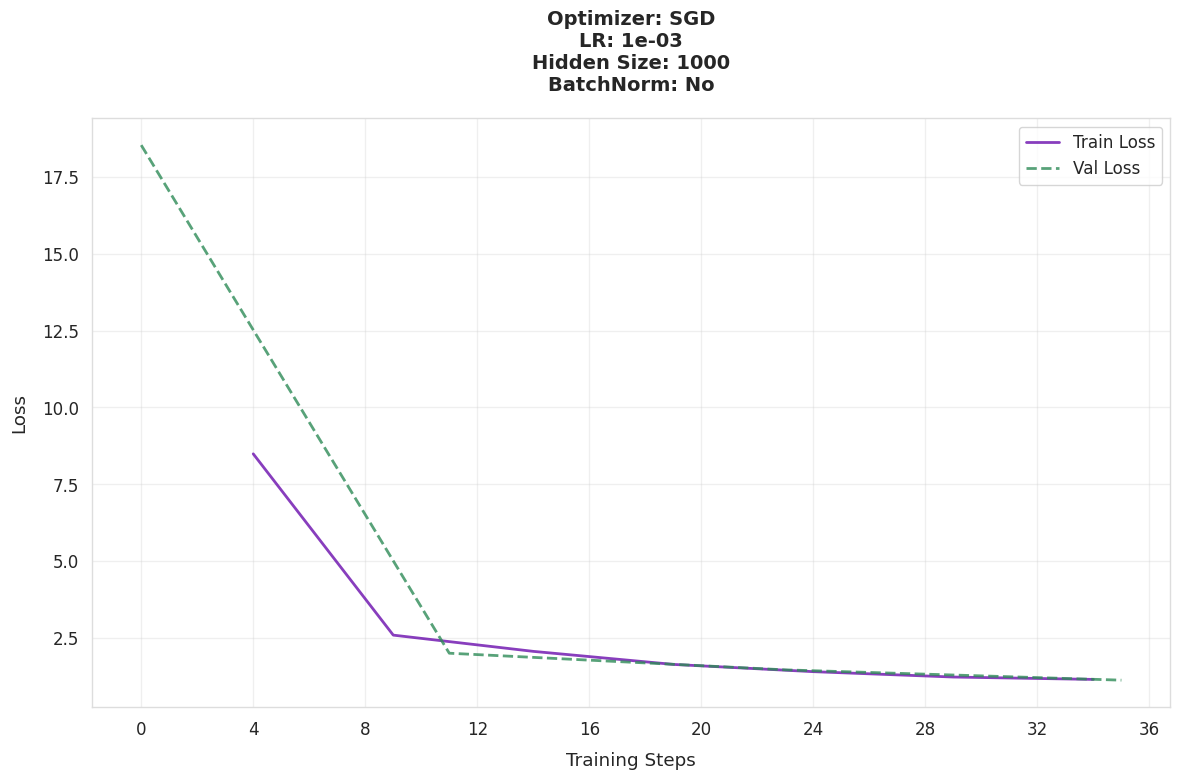

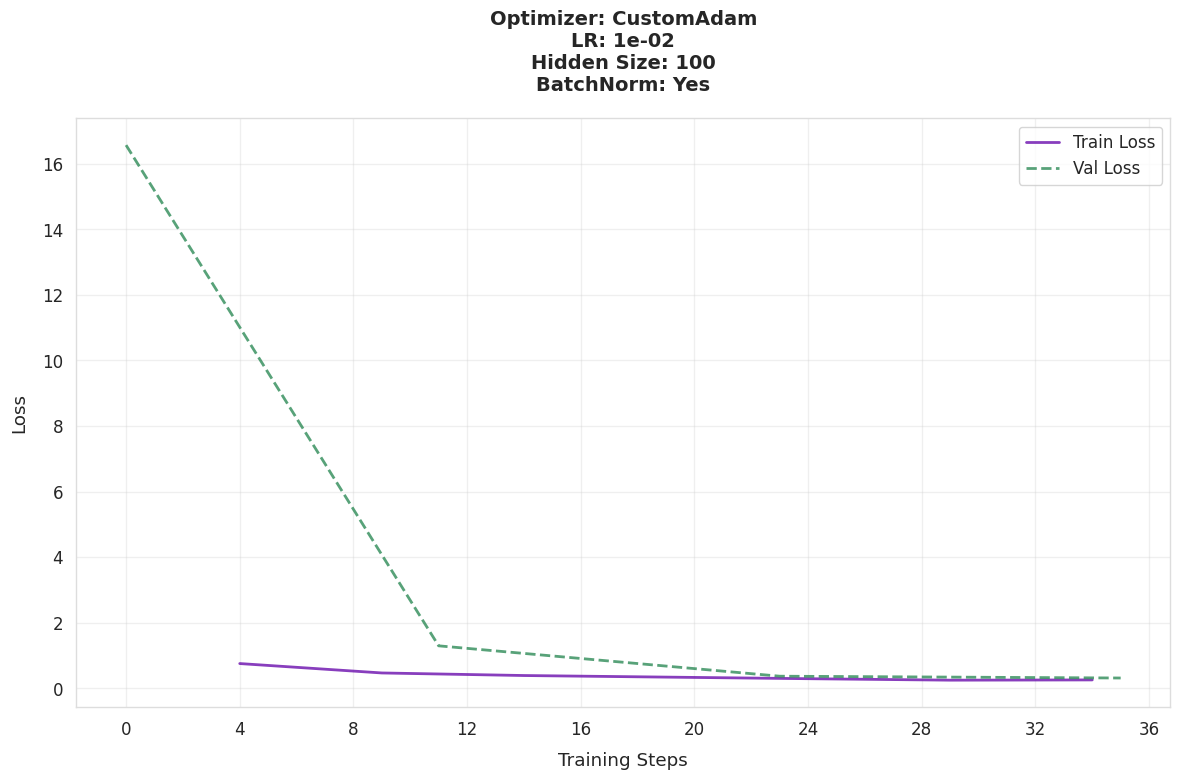

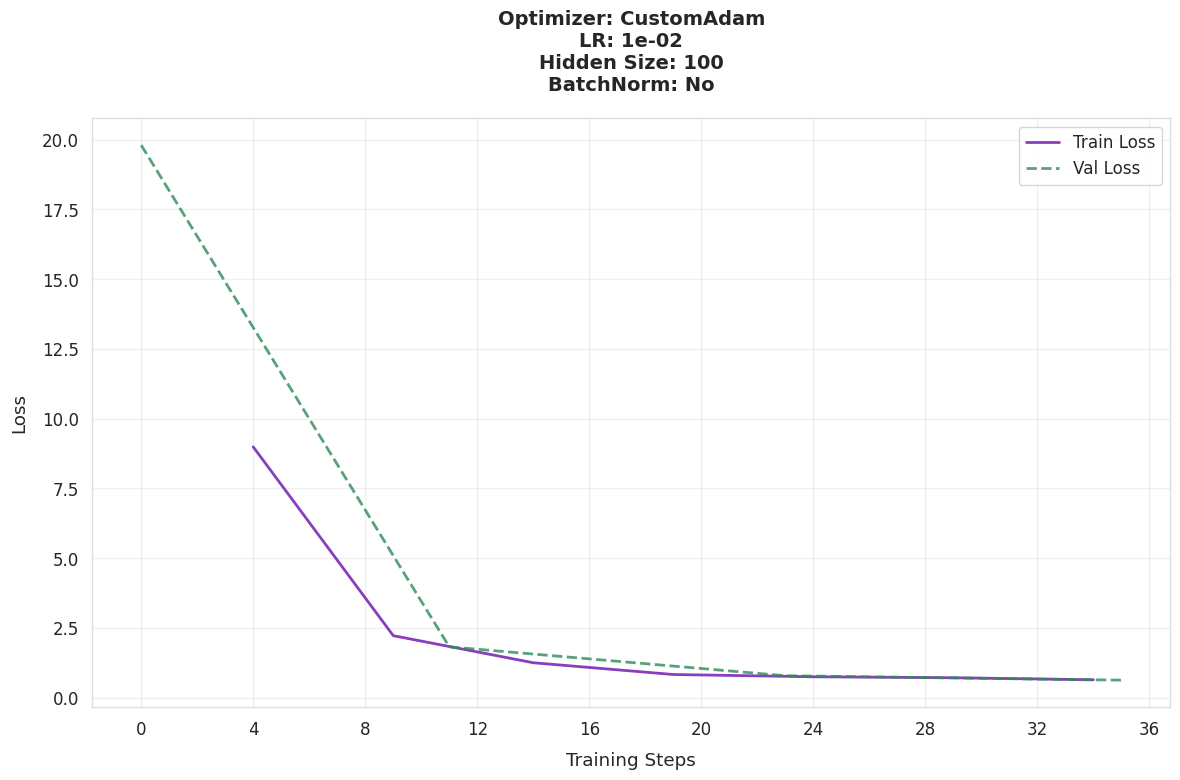


Val Acc Results:
+------------+---------------+-------------+-----------+---------+
| Optimizer  | Learning Rate | Hidden Size | BatchNorm | Val_Acc |
+------------+---------------+-------------+-----------+---------+
|    SGD     |     1e-02     |    1000     |    Yes    | 0.9333  |
| CustomAdam |     1e-02     |    1000     |    Yes    | 0.9173  |
| CustomAdam |     1e-03     |    1000     |    No     | 0.9108  |
| CustomAdam |     1e-02     |     100     |    Yes    | 0.9084  |
|  RMSprop   |     1e-03     |    1000     |    Yes    | 0.9063  |
|    SGD     |     1e-02     |    1000     |    No     | 0.8999  |
|    SGD     |     1e-03     |    1000     |    Yes    | 0.8926  |
|  RMSprop   |     1e-03     |     100     |    Yes    | 0.8916  |
|  RMSprop   |     1e-02     |    1000     |    No     | 0.8913  |
|  RMSprop   |     1e-03     |    1000     |    No     | 0.8910  |
| CustomAdam |     1e-02     |    1000     |    No     | 0.8865  |
| CustomAdam |     1e-03     |    1000     |

In [ ]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def training_results(versions):
    for version in versions:
        plt.figure(figsize=(12, 8))
        df = pd.read_csv(os.path.join(version, "metrics.csv"))
        with open(os.path.join(version, "hparams.yaml")) as f:
            hparams = yaml.safe_load(f)
        
        train_df = df.dropna(subset=["train_loss"])
        val_df = df.dropna(subset=["val_loss"])
        
        plt.plot(
            train_df["step"],
            train_df["train_loss"],
            color='#6a0dad',
            linestyle='-',
            linewidth=2,
            alpha=0.8,
            label='Train Loss'
        )
        
        plt.plot(
            val_df["step"],
            val_df["val_loss"],
            color='#2e8b57',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label='Val Loss'
        )
        
        title_parts = [
            f"Optimizer: {hparams['optimizer_type']}",
            f"LR: {hparams['learning_rate']:.0e}",
            f"Hidden Size: {hparams['h_size']}",
            f"BatchNorm: {'Yes' if hparams['batchnorm'] else 'No'}"
        ]
        plt.title("\n".join(title_parts), pad=20, fontsize=14, fontweight='bold')
        
        plt.xlabel("Training Steps", labelpad=10)
        plt.ylabel("Loss", labelpad=10)
        plt.legend(loc='upper right')
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        
        for spine in plt.gca().spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('#dddddd')
            spine.set_linewidth(1)
        
        plt.tight_layout()
        plt.show()

def training_results_as_table(versions, metric='test_acc'):
    table_data = []
    for version in versions:
        df = pd.read_csv(os.path.join(version, "metrics.csv")).dropna(subset=[metric])
        with open(os.path.join(version, "hparams.yaml")) as f:
            hparams = yaml.safe_load(f)
        
        best_metric = df[metric].max() if 'acc' in metric else df[metric].min()
        table_data.append([
            hparams['optimizer_type'],
            f"{hparams['learning_rate']:.0e}",
            hparams['h_size'],
            'Yes' if hparams['batchnorm'] else 'No',
            f"{best_metric:.4f}"
        ])
    
    reverse = True if 'acc' in metric or 'f1' in metric else False
    table_data.sort(key=lambda x: x[-1], reverse=reverse)

    print(tabulate(
        table_data,
        headers=['Optimizer', 'Learning Rate', 'Hidden Size', 'BatchNorm', metric.title()],
        tablefmt='pretty',
        floatfmt=".4f"
    ))


versions = sorted(glob(f"{INFO_DIR}/{HP_DIR}/*"))
training_results(versions)
training_results_as_table(versions, 'val_acc')

In [ ]:
SETTINGS = [
    ("SGD", 0.01, 1000, True),
    ("CustomAdam", 0.01, 1000, True),
    ("CustomAdam", 0.001, 1000, False),
    ("CustomAdam", 0.01, 100, True),
    ("RMSprop", 0.001, 1000, True)
]

run_training(RESULT_DIR, LEARNING_EPOCHS, SETTINGS)

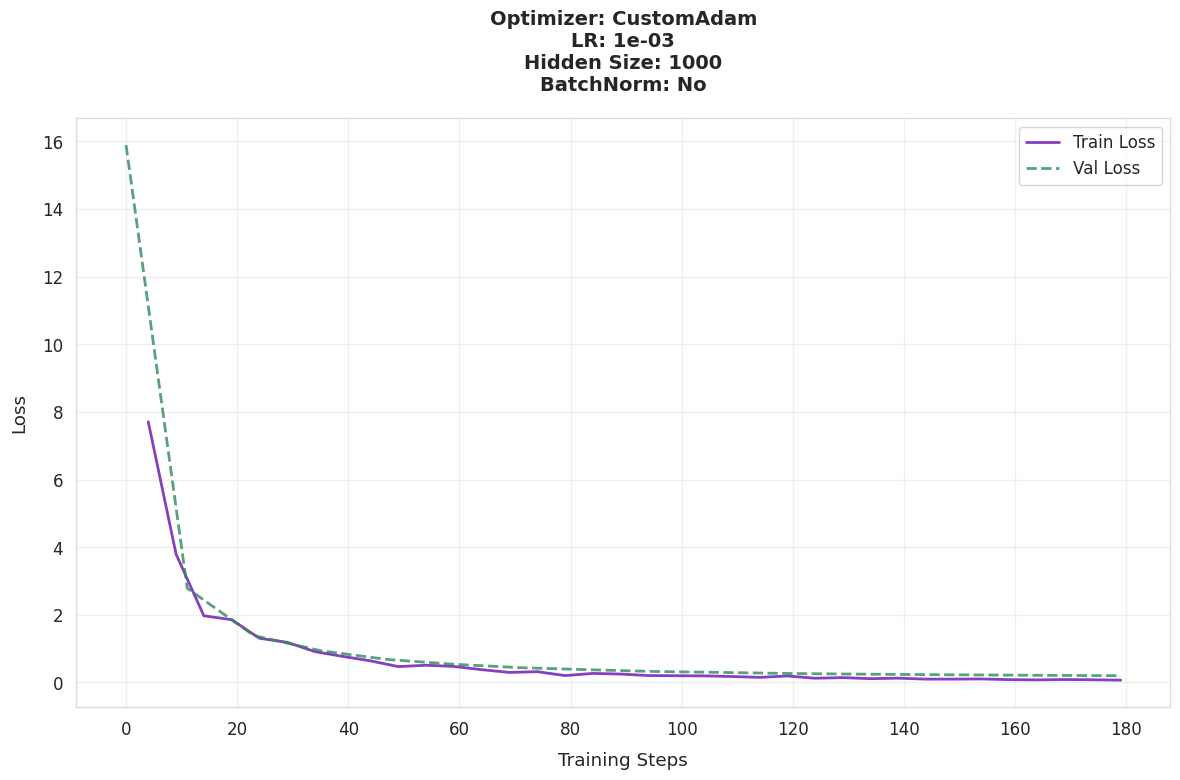

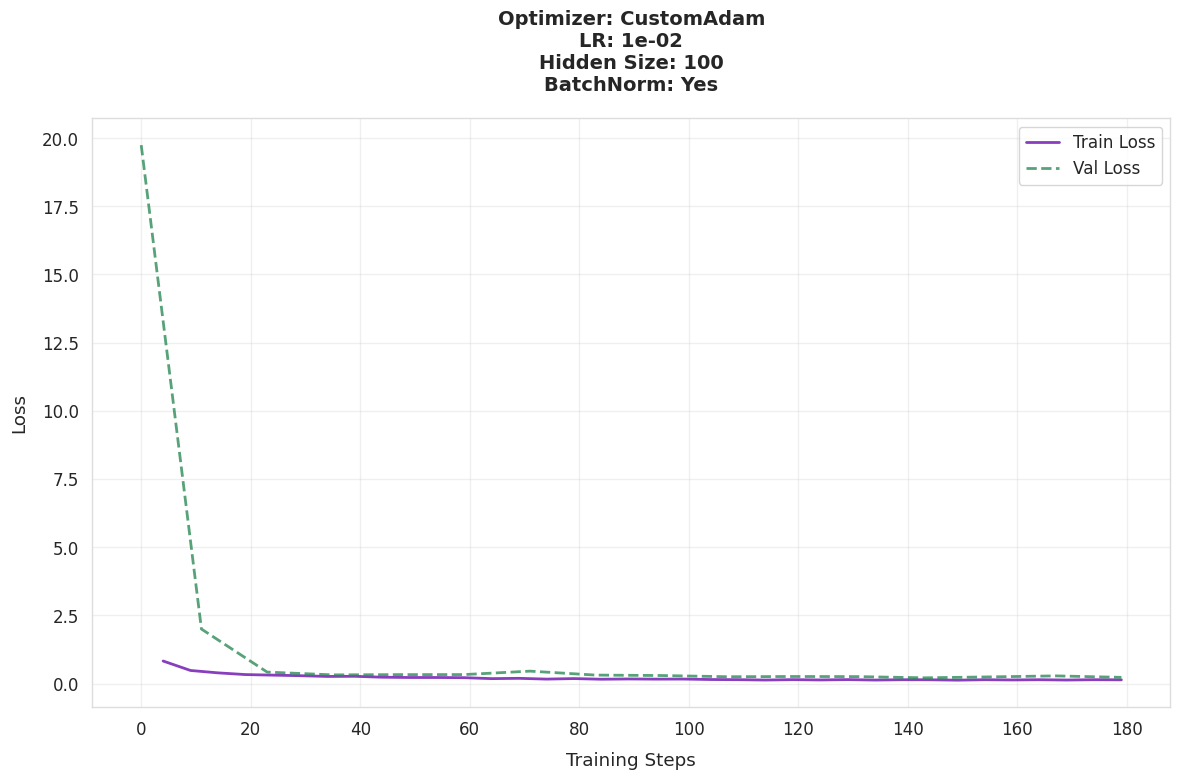

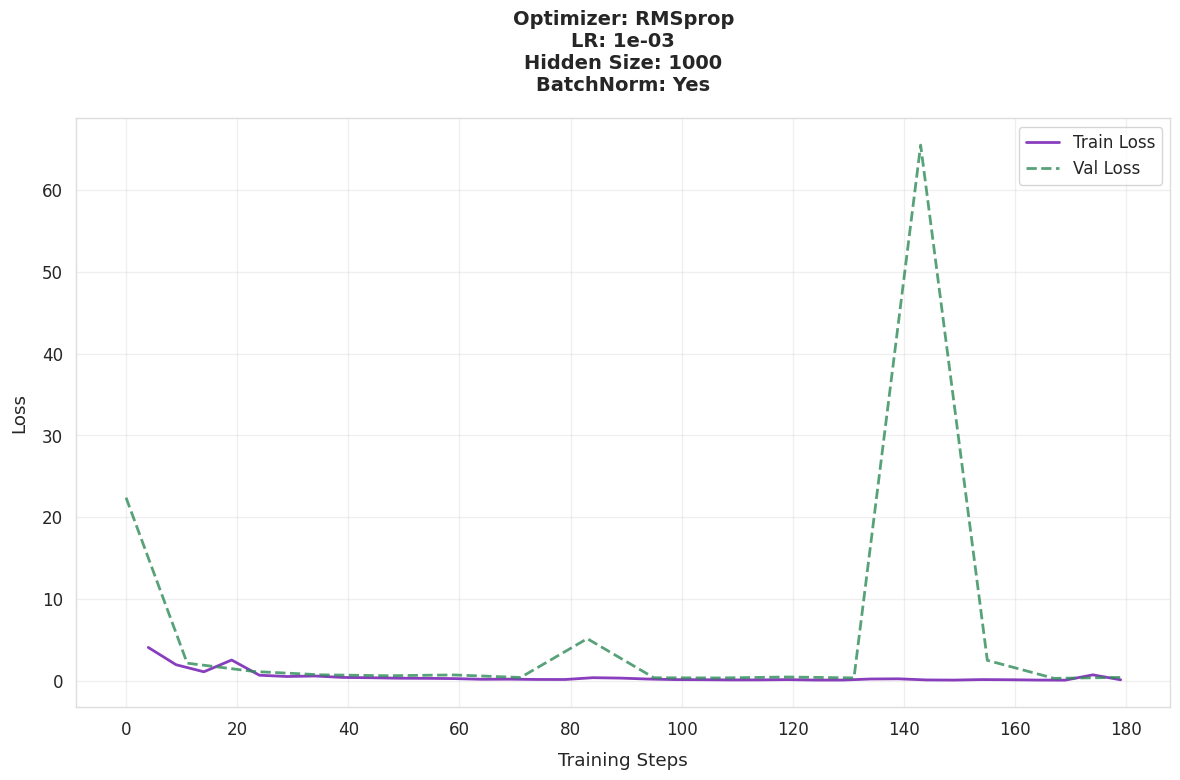

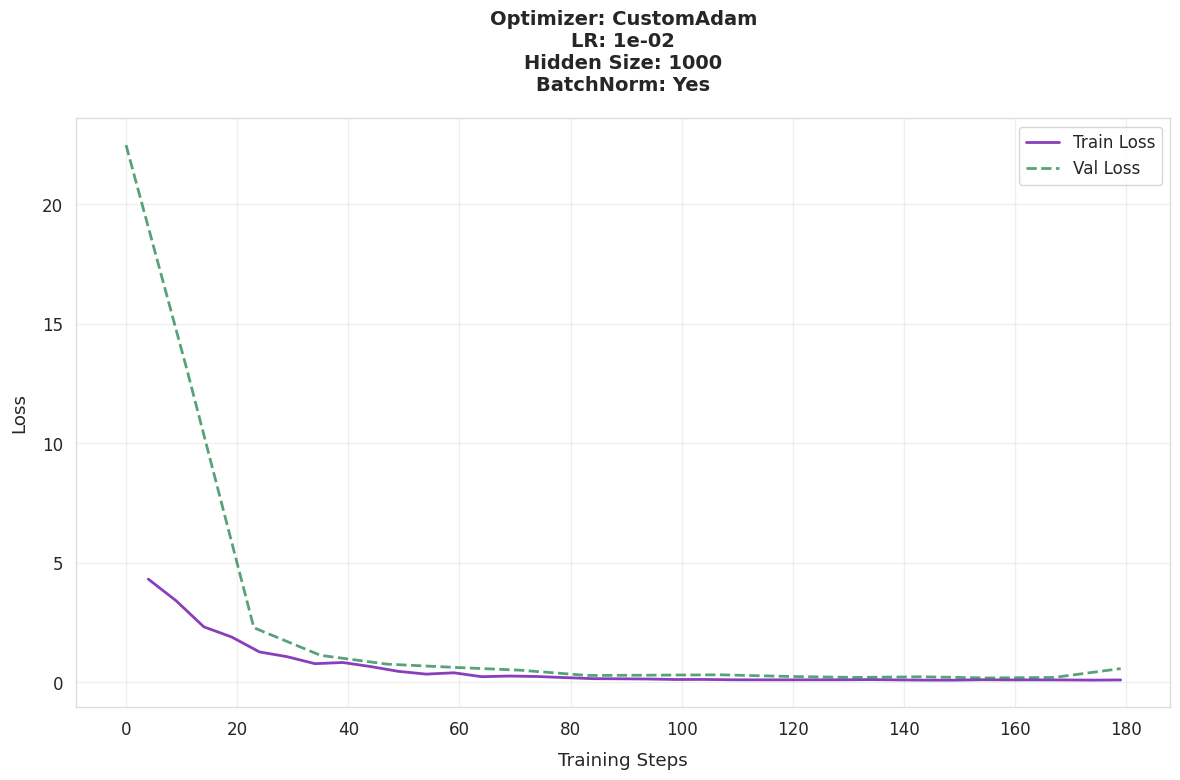

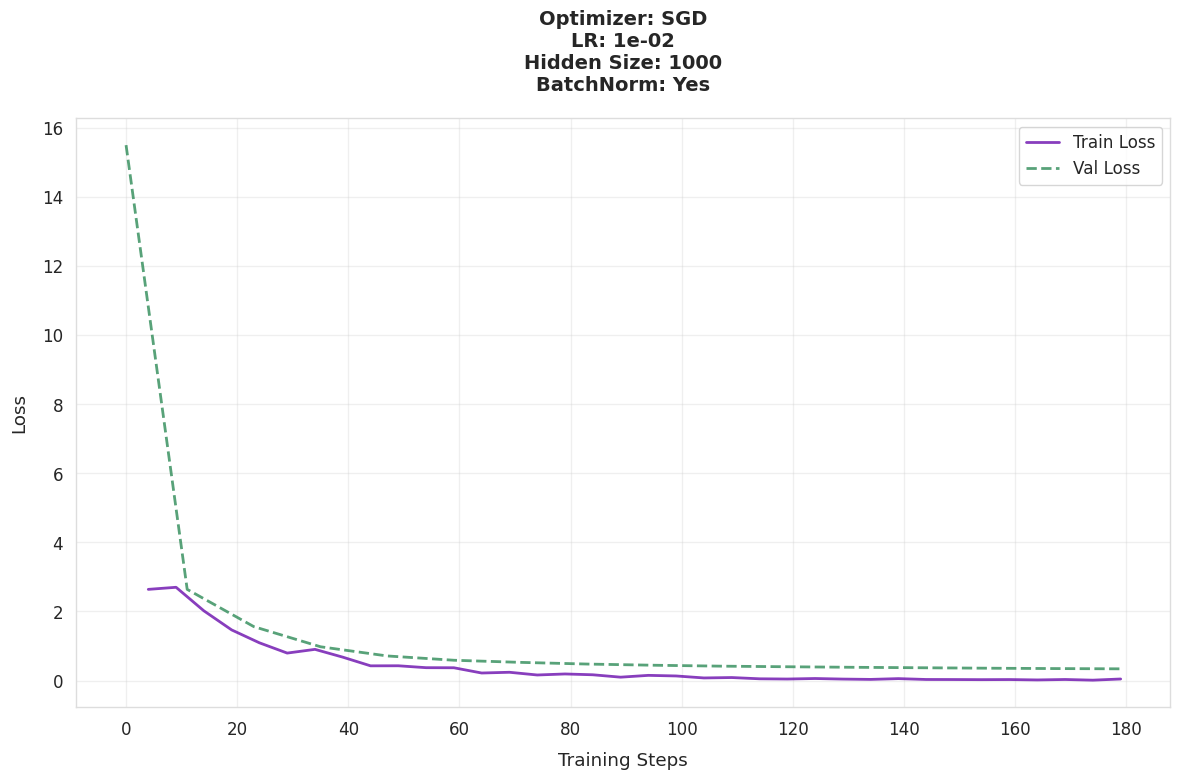


Test Acc Results:
+------------+---------------+-------------+-----------+----------+
| Optimizer  | Learning Rate | Hidden Size | BatchNorm | Test_Acc |
+------------+---------------+-------------+-----------+----------+
|    SGD     |     1e-02     |    1000     |    Yes    |  0.9591  |
| CustomAdam |     1e-03     |    1000     |    No     |  0.9565  |
|  RMSprop   |     1e-03     |    1000     |    Yes    |  0.9465  |
| CustomAdam |     1e-02     |     100     |    Yes    |  0.9442  |
| CustomAdam |     1e-02     |    1000     |    Yes    |  0.8646  |
+------------+---------------+-------------+-----------+----------+


In [ ]:
best_versions = glob(f"{INFO_DIR}/{RESULT_DIR}/*", recursive=True)
training_results(best_versions)
training_results_as_table(best_versions, 'test_acc')

### Результаты

Наилучшие результаты на тестовой выборке продемонстрировала следующая конфигурация:
- Оптимизатор: SGD
- Скорость обучения: 0.01
- Размер скрытого слоя: 1000 нейронов
- Batch Normalization: включен